# Extracting (non)seeds with `microbetag` 

In [ ]:
import logging

import matplotlib.pyplot as plt
import networkx as nx
from pyvis.network import Network

from microbetag.PhyloMint.lib.BuildGraphNetX import buildDG, getSeedSet


To enable seeing the `logger` messages in this notebook, we need to run fhe following: 

In [2]:
logging.basicConfig(level=logging.INFO)

## Using a paper-scale toy-model

Here, we deploy a toy-model to highlight how we can get seeds, their confidence scores and non-seeds, using `microbetag`'s implementation. 

Based on the PhyloMint paper, we will use the following example case:

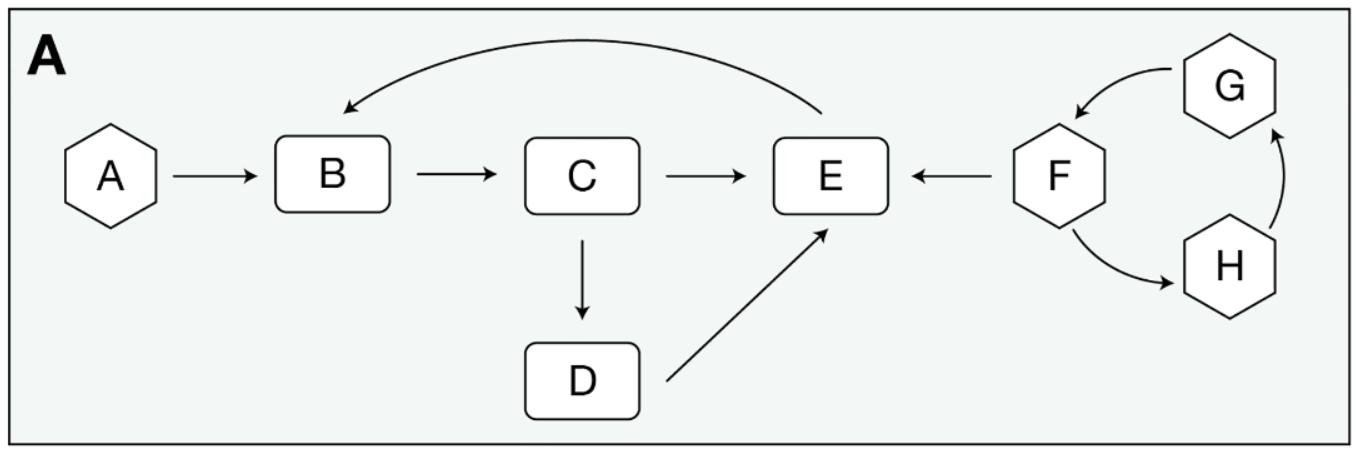

First, we will build the metabolic toy model of ours, and we will save it in `.html` and `.png` files. 

In [56]:
# --------------------------------------------------
# Create the graph
# --------------------------------------------------

net = Network(
    directed=True, notebook=True, width="100%", height="700px", bgcolor="#f5f8f7"
)

positions = {
    "A": (-600, 0),
    "B": (-350, 0),
    "C": (-100, 0),
    "D": (-100, 200),
    "E": (180, 0),
    "F": (430, 0),
    "H": (600, 180),
    "G": (600, -180),
}


In [58]:
# --------------------------------------------------
# Add nodes
# --------------------------------------------------

for node, (x, y) in positions.items():
    net.add_node(
        node,
        label=node,
        x=x,
        y=y,
        # Make position completely fixed
        fixed={"x": True, "y": True},
        physics=False,
        # Rounded rectangle like the figure
        shape="box",
        size=30,
        font={"size": 28, "face": "Arial"},
        borderWidth=2,
    )
# --------------------------------------------------
# Add edges
# --------------------------------------------------

# A -> B
net.add_edge("A", "B", arrows="to")

# B -> C
net.add_edge("B", "C", arrows="to")

# C -> E
net.add_edge("C", "E", arrows="to")

# C -> D
net.add_edge("C", "D", arrows="to")

# D -> E
net.add_edge("D", "E", arrows="to")

# F -> E
net.add_edge("F", "E", arrows="to")

# F -> H
net.add_edge("F", "H", arrows="to")

# H -> G
net.add_edge("H", "G", arrows="to")

# G -> F
net.add_edge("G", "F", arrows="to")

# E -> B
#
# Make this a large curved edge
net.add_edge(
    "E",
    "B",
    arrows="to",
    smooth={"enabled": True, "type": "curvedCCW", "roundness": 0.35},
)

In [ ]:
# --------------------------------------------------
# Disable physics
# --------------------------------------------------

net.toggle_physics(False)

# --------------------------------------------------
# Generate HTML
# --------------------------------------------------

net.show("scc_graph.html")


We will now convert the `pyvis.Network` object we built to a `networkx` directed graph (`networkx.DiGraph()`) which is the format that `microbetag` gets.

In [ ]:
# --------------------------------------------------
# Make networkx graph from Network object
# --------------------------------------------------
G = nx.DiGraph()

# Add nodes
for node in net.nodes:
    G.add_node(node["id"], **{k: v for k, v in node.items() if k != "id"})

# Add edges
for edge in net.edges:
    source = edge["from"]
    target = edge["to"]

    G.add_edge(
        source, target, **{k: v for k, v in edge.items() if k not in ("from", "to")}
    )


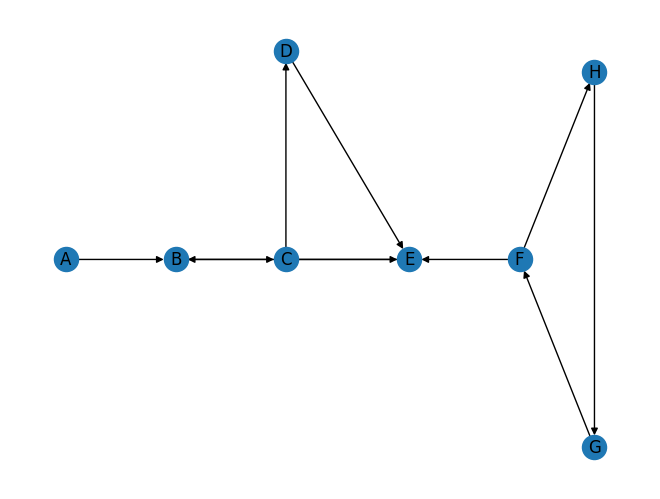

In [ ]:
# --------------------------------------------------
# Specify positions for networkx graph based on pyvis 
# node positions and plot using matplotlib
# --------------------------------------------------

pos = {}

for node in net.nodes:
    pos[node["id"]] = (node.get("x", 0), node.get("y", 0))


nx.draw(G, pos=pos, with_labels=True)

plt.savefig("graph.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
cs, ss, ns = getSeedSet(G)

In [16]:
print(f"Confidence scores:\n {cs}, \nSeed set:\n {ss}, \nNon-seed set:\n {ns}")

Confidence scores:
 {'A': 1.0, 'F': 0.3333333333333333, 'H': 0.3333333333333333, 'G': 0.3333333333333333}, 
Seed set:
 {'F', 'A', 'H', 'G'}, 
Non-seed set:
 ['C', 'B', 'E', 'D']


So, it seems to work fine! ;-)

## Using the `e_coli_core` model

However, originally `microbetag` makes use of two routines to get a metabolic model's (non)seed sets. 

Before extracting the seeds, `microbetag` needs to get the **directed graph** out of the metabolic model.

To this end, it makes use of the `buildDG()` function.


In [4]:
import cobra

cobra.Configuration().solver = "glpk"

Load the `e_coli_core` model


In [5]:
model = cobra.io.load_model("textbook")
len(model.metabolites), len(model.reactions)

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


(72, 95)

Here is the help message of the `buiildDG` function. 
The especially interesting part in terms of seed extraction is the `check_blocked` parameter.

In [22]:
help(buildDG)

Help on function buildDG in module microbetag.PhyloMint.lib.BuildGraphNetX:

buildDG(sbml: str, filter_currency: bool = True, check_blocked: bool = False, currency_set: set = None) -> networkx.classes.digraph.DiGraph
    Reads an SBML model (via cobrapy) and builds a directed compound
    graph suitable for seed-set (network expansion) analysis.
    
    Args:
        sbml: path to SBML model file
        filter_currency: whether to exclude ubiquitous cofactors/currency
            metabolites (water, ATP/ADP, protons, etc.) from the graph
        check_blocked: whether to run FVA (cobra.flux_analysis.
            find_blocked_reactions) and exclude reactions that cannot
            carry nonzero flux under the model's current constraints
            and medium. NOTE: blocked-ness is medium-dependent -- if
            comparing seed sets across models, make sure they are
            evaluated under the same defined medium, or set
            check_blocked=False for a medium-agnostic gr

The `check_blocked` parameter is by default set as `False`, allowing us to get a medium-agnostic graph and thus seed set.

There are cases though, that one may be interested in getting seed-like metabolites under a particular medium; having `check_blocked` as `True` would allow that. 

In [6]:
ecoli_dg = buildDG(model, filter_currency=True, check_blocked=False)

INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACALD ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound coa_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound nad_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound h_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound nadh_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACALDt ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACKr ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound atp_c from graph (reaction ACKr) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excludi

We can now visualize our directed graph in a straight forward way thanks to `pyvis.network.Network`:

In [ ]:
net = Network(directed=True)
net.from_nx(ecoli_dg)
net.show("ecoli_dg.html", notebook=False)

ecoli_dg.html


Our graph has been saved in the [`ecoli_dg.html`](./ecoli_dg.html) file. 

Now, we are good to extract (non)seed set and the confidence level of those:

In [21]:
conf, ss, ns = getSeedSet(ecoli_dg)

INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: for_e - has an incoming edge from 'pyr_c' (outside its SCC), so it is produced within the network rather than being a source
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: for_c - has an incoming edge from 'pyr_c' (outside its SCC), so it is produced within the network rather than being a source
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: ac_e - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: mal__L_c - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: lac__D_c - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: glu__L_e - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component


In [22]:
conf

{'fru_e': 1.0, 'fum_e': 1.0, 'glc__D_e': 1.0, 'gln__L_e': 1.0, 'mal__L_e': 1.0}

Let's see what the seed-like set would be, if we would focusing on that particular medium of this toy model.

In [26]:
ecoli_dg_blocked = buildDG(model, filter_currency=True, check_blocked=True)

INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Identified 8 blocked reactions via FVA
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACALD ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound coa_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound nad_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound h_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound nadh_c from graph (reaction ACALD) - flagged as a currency/cofactor metabolite
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACALDt ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: ACKr ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Excluding compound atp_c from graph (reaction ACKr) - flagged as

In [ ]:
net = Network(directed=True)
net.from_nx(ecoli_dg_blocked)
net.show("ecoli_dg_blocked.html", notebook=False)

ecoli_dg_blocked.html


As you can see in the graph, some metabolites are now missing.
For exapmle, `fum_e` is not in the graph any more. 
This is because now, the FVA-oriented check, led reaction `FUMt2_2` to be excluded since it was found blocked, i.e. there is no way this reaction may have a non-zero flux, under this medium. 

Aparently, the (non)seed sets have been changed, and if you look closer to the graph, you would probably expect a single-entry seed set. 

In [28]:
conf_blocked, ss_blocked, ns_blocked = getSeedSet(ecoli_dg_blocked)

INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: for_e - has an incoming edge from 'pyr_c' (outside its SCC), so it is produced within the network rather than being a source
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: for_c - has an incoming edge from 'pyr_c' (outside its SCC), so it is produced within the network rather than being a source
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: ac_e - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: mal__L_c - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: lac__D_c - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Non-seed: glu__L_e - member of an SCC of size 43 (> maxComponentSize=5); treated as a non-informative hub component


In [29]:
conf_blocked

{'glc__D_e': 1.0}

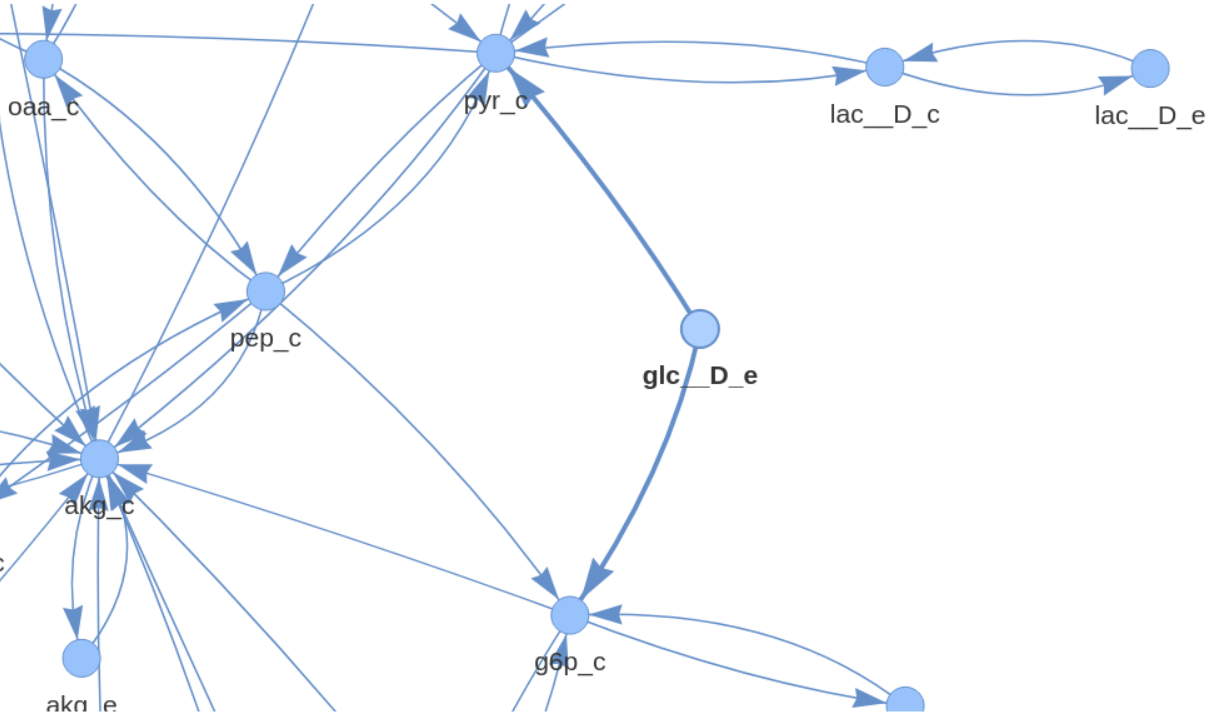

### Using a genome-scale model

You can now have a look on how the module behaves on real-world genome-scale models, using an example model of another test case of ours (see model at : [`<root_repo>/test_data/test_seed_compl/input_files/bin_101.xml`](../test_data/test_seed_compl/input_files/bin_101.xml))

In [30]:
gscm = cobra.io.read_sbml_model("../test_data/test_seed_compl/input_files/bin_101.xml")

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


In [ ]:
gscm_dg = buildDG(gscm, check_blocked=False)

INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: EX_26dap__M_e ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Skipping reaction EX_26dap__M_e - boundary/exchange reaction, touches only one compound
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: EX_2ddglcn_e ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Skipping reaction EX_2ddglcn_e - boundary/exchange reaction, touches only one compound
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: EX_2mpa_e ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Skipping reaction EX_2mpa_e - boundary/exchange reaction, touches only one compound
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: EX_3amp_e ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Skipping reaction EX_3amp_e - boundary/exchange reaction, touches only one compound
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:
 ~~ Processing reaction: EX_3cmp_e ~~
INFO:microbetag.PhyloMint.lib.BuildGraphNetX:Skipp

In [33]:
net = Network(
    directed=True,
    height="100vh",   # full viewport height
    width="100%",      # full viewport width
    bgcolor="#ffffff",
    font_color="black"
)
net.from_nx(gscm_dg)
net.show("gscm_dg.html", notebook=False)

gscm_dg.html


In [ ]:
gscm_conf, gscm_ss, gscm_ns = getSeedSet(gscm_dg)

We have removed the `logger`'s info to save the reader some space, but messages like above should be expected here. 

Let's now have a look on our seed set. 

In [ ]:
import pandas as pd

gscm_conf_df = (
    pd.DataFrame.from_dict(gscm_conf, orient="index")
    .reset_index()
)
gscm_conf_df.columns = ["seed", "confidence"]
gscm_conf_df.head(10)

,seed,confidence
0,26dap__M_e,0.500000
1,26dap__M_p,0.500000
2,3amp_e,1.000000
3,3cmp_e,1.000000
4,3oxoadp_e,0.500000
5,3oxoadp_p,0.500000
6,1p3h5c_c,0.333333
7,4hpro_LT_c,0.333333
8,4hpro_LT_e,0.333333
9,5mtr_e,1.000000


The number of compounds found as seeds: 

In [55]:
gscm_conf_df.shape

(163, 2)